In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
df=pd.read_pickle('/content/drive/MyDrive/LSWMD.pkl')

In [5]:
print(df.shape)

(811457, 6)


In [6]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [7]:
# ── Extract waferMap + failureType for ALL 811K rows ─────────────────────────
data = df[['waferMap', 'failureType']].copy()

# Flatten the failureType field (it is stored as nested arrays in the pkl)
def extract_label(x):
    val = np.squeeze(x)
    # numpy array with shape () or (1,) → single string
    if val.ndim == 0:
        return str(val).strip()
    # empty array → unlabeled
    if val.size == 0:
        return 'unlabeled'
    return str(val.flat[0]).strip()

data['failureType'] = data['failureType'].apply(extract_label)

# Mark truly unlabeled rows (empty string or literal '[]')
data.loc[data['failureType'].isin(['', '[]', 'nan']), 'failureType'] = 'unlabeled'

print('Raw label distribution (ALL 811K rows):')
print(data['failureType'].value_counts())
print(f'\nTotal rows          : {len(data):,}')
print(f'Labeled rows        : {(data["failureType"] != "unlabeled").sum():,}')
print(f'Unlabeled rows      : {(data["failureType"] == "unlabeled").sum():,}')

Raw label distribution (ALL 811K rows):
failureType
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Total rows          : 811,457
Labeled rows        : 172,950
Unlabeled rows      : 638,507


Labeled samples  : 172,950
Unlabeled samples: 638,507

Labeled class breakdown:
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


/tmp/ipykernel_4876/2580798937.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[0])


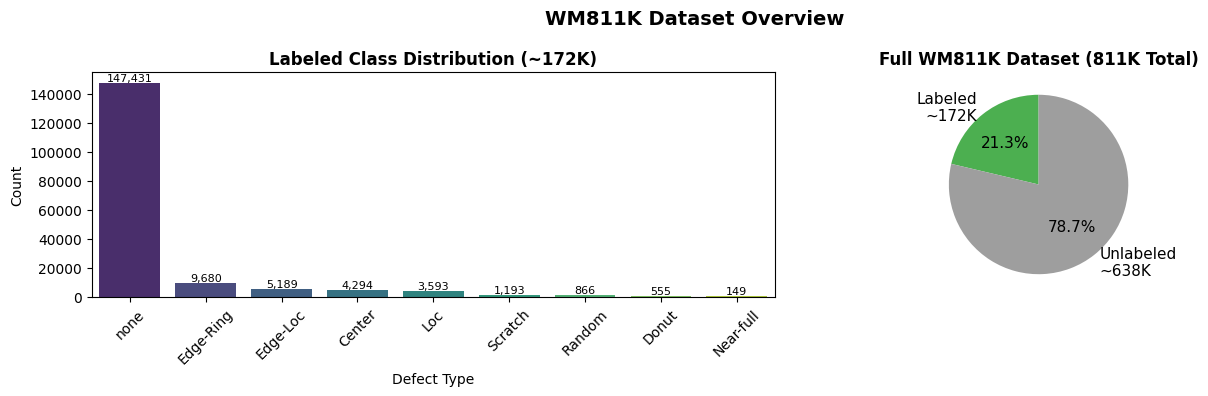

⚠️  Highly imbalanced: none dominates labeled; 638K wafers have no label!


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY: Use ALL 811K wafers
#
#  labeled  (~172K): have a known defect class → used for supervised training
#  unlabeled (~638K): no class label           → used as EXTRA augmentation
#                     source for minority classes during balancing
#
# Why unlabeled data helps:
#   • Real wafer textures & noise patterns → Albumentations on them is more
#     realistic than augmenting the same 50 scratch images 60× over
#   • Acts as pseudo-background pool: we augment them and assign the SAME
#     minority class label (semi-supervised trick to pad rare classes)
# ─────────────────────────────────────────────────────────────────────────────

DEFECT_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Random', 'Scratch', 'Near-full', 'none']

# Separate labeled and unlabeled
labeled_data   = data[data['failureType'].isin(DEFECT_CLASSES)].reset_index(drop=True)
unlabeled_data = data[data['failureType'] == 'unlabeled'].reset_index(drop=True)

print(f'Labeled samples  : {len(labeled_data):,}')
print(f'Unlabeled samples: {len(unlabeled_data):,}')
print()
print('Labeled class breakdown:')
print(labeled_data['failureType'].value_counts())

# ── Plot labeled class distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = labeled_data['failureType'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Labeled Class Distribution (~172K)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Defect Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Pie: labeled vs unlabeled in full 811K
axes[1].pie(
    [len(labeled_data), len(unlabeled_data)],
    labels=['Labeled\n~172K', 'Unlabeled\n~638K'],
    colors=['#4CAF50', '#9E9E9E'],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Full WM811K Dataset (811K Total)', fontsize=12, fontweight='bold')

plt.suptitle('WM811K Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print('⚠️  Highly imbalanced: none dominates labeled; 638K wafers have no label!')

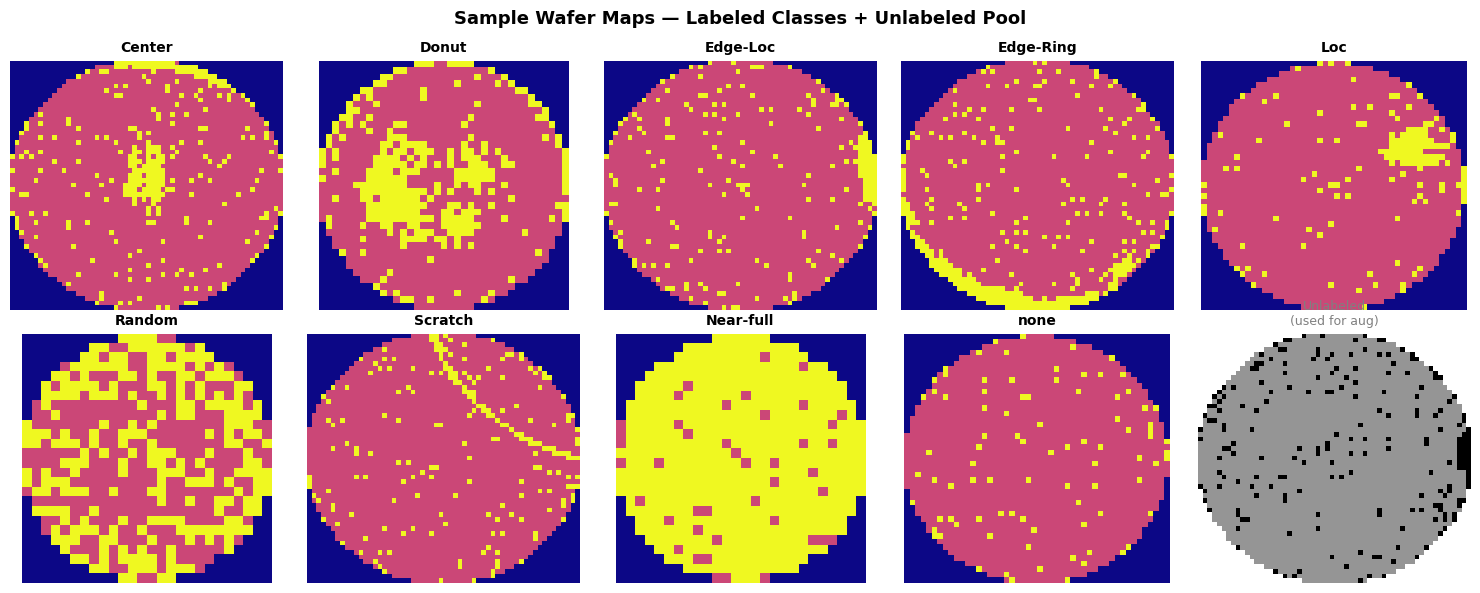

In [9]:
# ── Visualise one sample per labeled class ────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for idx, cls in enumerate(DEFECT_CLASSES):
    sample = labeled_data[labeled_data['failureType'] == cls]['waferMap'].iloc[0]
    axes[idx].imshow(np.array(sample), cmap='plasma')
    axes[idx].set_title(cls, fontsize=10, fontweight='bold')
    axes[idx].axis('off')
# Show an unlabeled sample in the 10th slot
unlabeled_sample = unlabeled_data['waferMap'].iloc[0]
axes[-1].imshow(np.array(unlabeled_sample), cmap='Greys')
axes[-1].set_title('Unlabeled\n(used for aug)', fontsize=9, color='gray')
axes[-1].axis('off')
plt.suptitle('Sample Wafer Maps — Labeled Classes + Unlabeled Pool',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_wafers.png', dpi=150)
plt.show()

In [10]:
import cv2
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64   # Use 224 if you have GPU; 64 is safe for CPU demo

def wafer_to_img(wafer, size=IMG_SIZE):
    """Convert 2D wafer map (values 0/1/2) to uint8 image."""
    arr = np.array(wafer, dtype=np.uint8)
    # Map pixel values: 0=background, 1=normal die, 2=defect → scale to 0-255
    arr = (arr * 127).clip(0, 255).astype(np.uint8)
    img = cv2.resize(arr, (size, size), interpolation=cv2.INTER_NEAREST)
    img = np.stack([img]*3, axis=-1)  # Grayscale → 3-channel
    return img

# ── Encode labels from labeled_data only ─────────────────────────────────────
le = LabelEncoder()
labeled_data = labeled_data.copy()
labeled_data['label'] = le.fit_transform(labeled_data['failureType'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# ── Quick sanity check ────────────────────────────────────────────────────────
sample_img = wafer_to_img(labeled_data['waferMap'].iloc[0])
print(f'Image shape: {sample_img.shape}, dtype: {sample_img.dtype}')
print(f'Unlabeled pool size available for augmentation: {len(unlabeled_data):,}')

Classes (9): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
Image shape: (64, 64, 3), dtype: uint8
Unlabeled pool size available for augmentation: 638,507


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_4876/494774764.py:14: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=8, max_width=8, p=0.3),  # simulate missing dies


Converting 10,000 unlabeled wafers to images...


100%|██████████| 10000/10000 [00:00<00:00, 25322.85it/s]


✅ Unlabeled pool ready: 10,000 images

Balancing to 3000 samples per class...


Classes: 100%|██████████| 9/9 [00:14<00:00,  1.59s/it]



✅ Final balanced dataset: (27000, 64, 64, 3)

Class counts after balancing:
  Center      : 3,000
  Donut       : 3,000
  Edge-Loc    : 3,000
  Edge-Ring   : 3,000
  Loc         : 3,000
  Near-full   : 3,000
  Random      : 3,000
  Scratch     : 3,000
  none        : 3,000


/tmp/ipykernel_4876/494774764.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=before_counts.index, y=before_counts.values,
/tmp/ipykernel_4876/494774764.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after_counts.keys()), y=list(after_counts.values()),


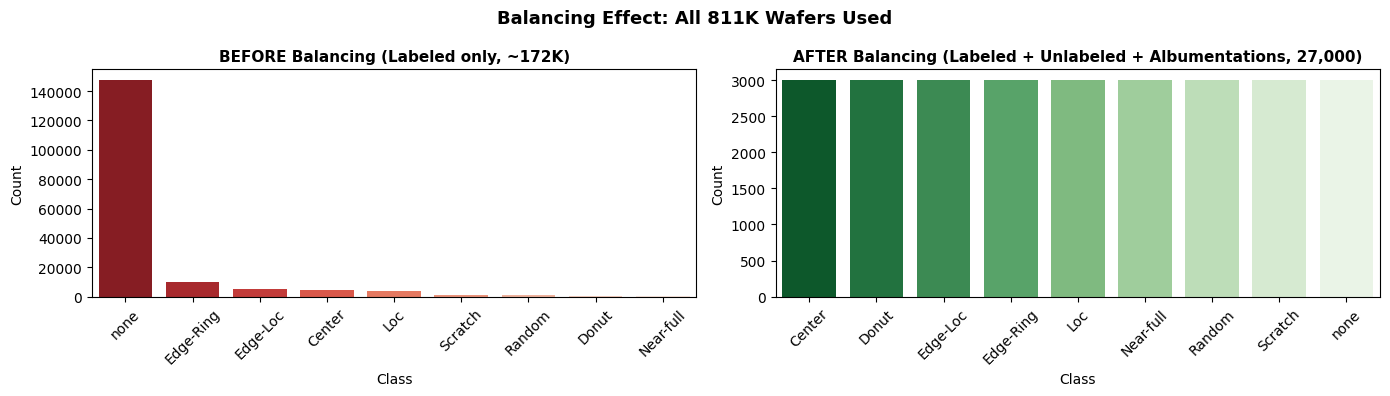

✅ Dataset fully balanced using labeled + unlabeled + Albumentations!


In [11]:
import albumentations as A
from tqdm import tqdm
import random

# ── Albumentations pipeline ───────────────────────────────────────────────────
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=10, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8, p=0.3),  # simulate missing dies
])

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY: labeled + unlabeled combined for balancing
#
# 1. For each defect class, start with ALL its labeled images (originals kept)
# 2. If still short of TARGET_PER_CLASS:
#    a) First re-augment existing labeled images (they carry real pattern info)
#    b) Then pull from the UNLABELED POOL and augment those too
#       → unlabeled wafers contribute real device textures & noise statistics
#       → they do NOT carry class info, so they are only used to pad
#         minority classes (semi-supervised augmentation trick)
# 3. The 'none' class is already majority; cap it at TARGET_PER_CLASS too
#    so it doesn't dominate training
# ─────────────────────────────────────────────────────────────────────────────

TARGET_PER_CLASS = 3000   # 5K per class → 45K total balanced dataset
                           # Increase to 10000 on GPU for better results

# Pre-convert unlabeled wafers to images once (random subsample to save RAM)
UNLABELED_POOL_SIZE = 10000   # Use 20K unlabeled wafers as augmentation pool
unlabeled_pool_df = unlabeled_data.sample(
    min(UNLABELED_POOL_SIZE, len(unlabeled_data)), random_state=42)
print(f'Converting {len(unlabeled_pool_df):,} unlabeled wafers to images...')
unlabeled_pool_imgs = [wafer_to_img(w) for w in tqdm(unlabeled_pool_df['waferMap'])]
print(f'✅ Unlabeled pool ready: {len(unlabeled_pool_imgs):,} images')

# ── Main balancing loop ───────────────────────────────────────────────────────
balanced_images = []
balanced_labels = []

print(f'\nBalancing to {TARGET_PER_CLASS} samples per class...')
for cls_name in tqdm(CLASS_NAMES, desc='Classes'):
    cls_df     = labeled_data[labeled_data['failureType'] == cls_name]
    cls_label  = le.transform([cls_name])[0]
    labeled_imgs = [wafer_to_img(w) for w in cls_df['waferMap']]

    count = 0

    # --- Phase 1: Add all original labeled images first (no augmentation) ----
    for img in labeled_imgs:
        if count >= TARGET_PER_CLASS:
            break
        balanced_images.append(img)
        balanced_labels.append(cls_label)
        count += 1

    # --- Phase 2: Augment labeled images to fill up to TARGET ----------------
    lab_idx = 0
    while count < TARGET_PER_CLASS and count < TARGET_PER_CLASS * 0.75:
        # Re-augment a labeled image (cycles through labeled pool)
        src_img = labeled_imgs[lab_idx % len(labeled_imgs)]
        aug_img = augment(image=src_img)['image']
        balanced_images.append(aug_img)
        balanced_labels.append(cls_label)
        count += 1
        lab_idx += 1

    # --- Phase 3: Pull from UNLABELED pool for remaining gap -----------------
    # These unlabeled wafers provide real device-level texture diversity
    unlab_idx = 0
    while count < TARGET_PER_CLASS:
        src_img = unlabeled_pool_imgs[unlab_idx % len(unlabeled_pool_imgs)]
        aug_img = augment(image=src_img)['image']
        balanced_images.append(aug_img)
        balanced_labels.append(cls_label)
        count += 1
        unlab_idx += 1

# ── Shuffle and convert ───────────────────────────────────────────────────────
combined = list(zip(balanced_images, balanced_labels))
random.shuffle(combined)
balanced_images, balanced_labels = zip(*combined)

X_all = np.array(balanced_images, dtype=np.float32) / 255.0   # Normalize [0,1]
y_all = np.array(balanced_labels)

print(f'\n✅ Final balanced dataset: {X_all.shape}')
print('\nClass counts after balancing:')
unique, counts_ = np.unique(y_all, return_counts=True)
for u, c in zip(unique, counts_):
    print(f'  {CLASS_NAMES[u]:12s}: {c:,}')

# ── Before / After comparison chart ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

before_counts = labeled_data['failureType'].value_counts()
sns.barplot(x=before_counts.index, y=before_counts.values,
            palette='Reds_r', ax=axes[0])
axes[0].set_title('BEFORE Balancing (Labeled only, ~172K)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

after_counts = dict(zip([CLASS_NAMES[u] for u in unique], counts_))
sns.barplot(x=list(after_counts.keys()), y=list(after_counts.values()),
            palette='Greens_r', ax=axes[1])
axes[1].set_title(f'AFTER Balancing (Labeled + Unlabeled + Albumentations, {len(X_all):,})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Class'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Balancing Effect: All 811K Wafers Used', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('balancing_comparison.png', dpi=150)
plt.show()
print('✅ Dataset fully balanced using labeled + unlabeled + Albumentations!')

In [12]:
X_all.shape

(27000, 64, 64, 3)

In [13]:
from sklearn.model_selection import train_test_split

# 70% train | 15% val | 15% test  (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {X_train.shape[0]}')
print(f'Val   : {X_val.shape[0]}')
print(f'Test  : {X_test.shape[0]}')

Train : 18900
Val   : 4050
Test  : 4050


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

class WaferDataset(Dataset):
    def __init__(self, images, labels):
        # images: (N, H, W, 3) float32 → convert to (N, 3, H, W)
        self.images = torch.tensor(images).permute(0, 3, 1, 2)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

BATCH_SIZE = 64
train_loader = DataLoader(WaferDataset(X_train, y_train), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(WaferDataset(X_val,   y_val),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(WaferDataset(X_test,  y_test),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
print('✅ DataLoaders ready.')

Using device: cuda
✅ DataLoaders ready.


In [15]:
class WaferCNN(nn.Module):
    """Lightweight CNN for wafer defect classification."""
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = WaferCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN Parameters: {total_params:,}')
print(cnn_model)

CNN Parameters: 175,401
WaferCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1

In [16]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_model(model, train_loader, val_loader,
                epochs=15, lr=1e-3, model_name='model'):
    """Generic training loop with early stopping."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            t_loss   += loss.item() * imgs.size(0)
            t_correct += (preds.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs)
                loss = criterion(preds, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (preds.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        scheduler.step()

        t_acc = t_correct / t_total
        v_acc = v_correct / v_total
        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')

        print(f'Epoch {epoch:3d}/{epochs}  '
              f'TrainLoss={t_loss/t_total:.4f}  TrainAcc={t_acc:.4f}  '
              f'ValLoss={v_loss/v_total:.4f}  ValAcc={v_acc:.4f}')

    print(f'\n✅ Best Val Accuracy ({model_name}): {best_val_acc:.4f}')
    return history

In [17]:
# ── Train CNN ─────────────────────────────────────────────────────────────────
cnn_history = train_model(cnn_model, train_loader, val_loader,
                           epochs=15, lr=1e-3, model_name='cnn')

Epoch   1/15  TrainLoss=1.4968  TrainAcc=0.4311  ValLoss=1.1004  ValAcc=0.5652
Epoch   2/15  TrainLoss=1.1490  TrainAcc=0.5683  ValLoss=1.0845  ValAcc=0.6062
Epoch   3/15  TrainLoss=1.0264  TrainAcc=0.6149  ValLoss=1.1285  ValAcc=0.6005
Epoch   4/15  TrainLoss=0.9432  TrainAcc=0.6475  ValLoss=0.7909  ValAcc=0.7062
Epoch   5/15  TrainLoss=0.8662  TrainAcc=0.6766  ValLoss=0.7713  ValAcc=0.7240
Epoch   6/15  TrainLoss=0.8314  TrainAcc=0.6834  ValLoss=0.6874  ValAcc=0.7333
Epoch   7/15  TrainLoss=0.7967  TrainAcc=0.6969  ValLoss=0.6935  ValAcc=0.7417
Epoch   8/15  TrainLoss=0.7680  TrainAcc=0.7095  ValLoss=0.6487  ValAcc=0.7565
Epoch   9/15  TrainLoss=0.7372  TrainAcc=0.7182  ValLoss=0.6722  ValAcc=0.7506
Epoch  10/15  TrainLoss=0.7303  TrainAcc=0.7220  ValLoss=0.6458  ValAcc=0.7536
Epoch  11/15  TrainLoss=0.7064  TrainAcc=0.7325  ValLoss=0.6628  ValAcc=0.7536
Epoch  12/15  TrainLoss=0.7009  TrainAcc=0.7346  ValLoss=0.6429  ValAcc=0.7583
Epoch  13/15  TrainLoss=0.6843  TrainAcc=0.7392  Val

In [18]:
class HybridCNNTransformer(nn.Module):
    """
    Hybrid CNN-Transformer:
    - CNN extracts local texture features
    - Transformer Encoder captures global spatial dependencies
    """
    def __init__(self, num_classes=9, img_size=64, d_model=128, nhead=4,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.img_size = img_size

        # ── Local feature extractor (CNN backbone) ────────────────────────────
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32x32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16
            nn.Conv2d(64, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
            # Output: (B, d_model, H', W')
        )

        # ── Positional encoding (learnable) ───────────────────────────────────
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        # ── Transformer encoder ───────────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Classifier head ───────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # CNN features
        feat = self.cnn_backbone(x)           # (B, d_model, H', W')
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)  # (B, seq_len, d_model)

        # Add positional encoding
        feat = feat + self.pos_embed[:, :feat.size(1), :]

        # Transformer
        feat = self.transformer(feat)          # (B, seq_len, d_model)

        # Global average pool then classify
        feat = feat.mean(dim=1)                # (B, d_model)
        return self.head(feat)

hybrid_model = HybridCNNTransformer(NUM_CLASSES).to(DEVICE)
total_params_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f'Hybrid Parameters: {total_params_h:,}')

Hybrid Parameters: 558,601


In [19]:
hybrid_history = train_model(hybrid_model, train_loader, val_loader,
                              epochs=15, lr=5e-4, model_name='hybrid')

Epoch   1/15  TrainLoss=0.9473  TrainAcc=0.6471  ValLoss=0.5665  ValAcc=0.7852
Epoch   2/15  TrainLoss=0.5509  TrainAcc=0.7897  ValLoss=0.7045  ValAcc=0.7407
Epoch   3/15  TrainLoss=0.4750  TrainAcc=0.8165  ValLoss=0.5691  ValAcc=0.7919
Epoch   4/15  TrainLoss=0.4122  TrainAcc=0.8377  ValLoss=0.5522  ValAcc=0.7844
Epoch   5/15  TrainLoss=0.3770  TrainAcc=0.8511  ValLoss=0.4356  ValAcc=0.8217
Epoch   6/15  TrainLoss=0.3493  TrainAcc=0.8604  ValLoss=0.5607  ValAcc=0.7948
Epoch   7/15  TrainLoss=0.3204  TrainAcc=0.8693  ValLoss=0.4124  ValAcc=0.8390
Epoch   8/15  TrainLoss=0.2977  TrainAcc=0.8778  ValLoss=0.4440  ValAcc=0.8402
Epoch   9/15  TrainLoss=0.2671  TrainAcc=0.8889  ValLoss=0.4233  ValAcc=0.8462
Epoch  10/15  TrainLoss=0.2468  TrainAcc=0.8955  ValLoss=0.4397  ValAcc=0.8395
Epoch  11/15  TrainLoss=0.2207  TrainAcc=0.9065  ValLoss=0.3978  ValAcc=0.8521
Epoch  12/15  TrainLoss=0.2043  TrainAcc=0.9116  ValLoss=0.3922  ValAcc=0.8627
Epoch  13/15  TrainLoss=0.1913  TrainAcc=0.9186  Val

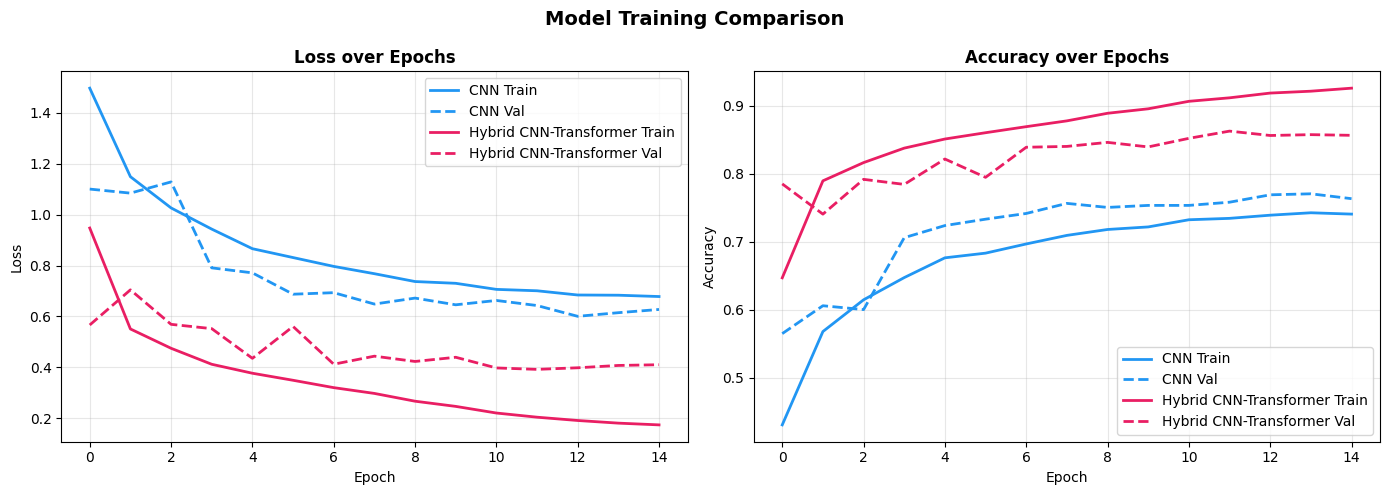

In [20]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#E91E63', '#4CAF50']
    for hist, name, col in zip(histories, names, colors):
        axes[0].plot(hist['train_loss'], label=f'{name} Train', color=col, linewidth=2)
        axes[0].plot(hist['val_loss'],   label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')
        axes[1].plot(hist['train_acc'],  label=f'{name} Train', color=col, linewidth=2)
        axes[1].plot(hist['val_acc'],    label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')

    axes[0].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Model Training Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(
    [cnn_history, hybrid_history],
    ['CNN', 'Hybrid CNN-Transformer']
)
# Add vit_history to the list if ViT training was run


===== cnn — Test Set Evaluation =====
Overall Accuracy : 0.7723 (77.23%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9220    0.7356    0.8183       450
       Donut     0.6652    0.6844    0.6747       450
    Edge-Loc     0.8679    0.8178    0.8421       450
   Edge-Ring     1.0000    0.9267    0.9619       450
         Loc     0.6391    0.7044    0.6702       450
   Near-full     0.9384    0.7444    0.8302       450
      Random     0.9085    0.6178    0.7354       450
     Scratch     0.4506    0.7711    0.5689       450
        none     0.9323    0.9489    0.9405       450

    accuracy                         0.7723      4050
   macro avg     0.8138    0.7723    0.7825      4050
weighted avg     0.8138    0.7723    0.7825      4050



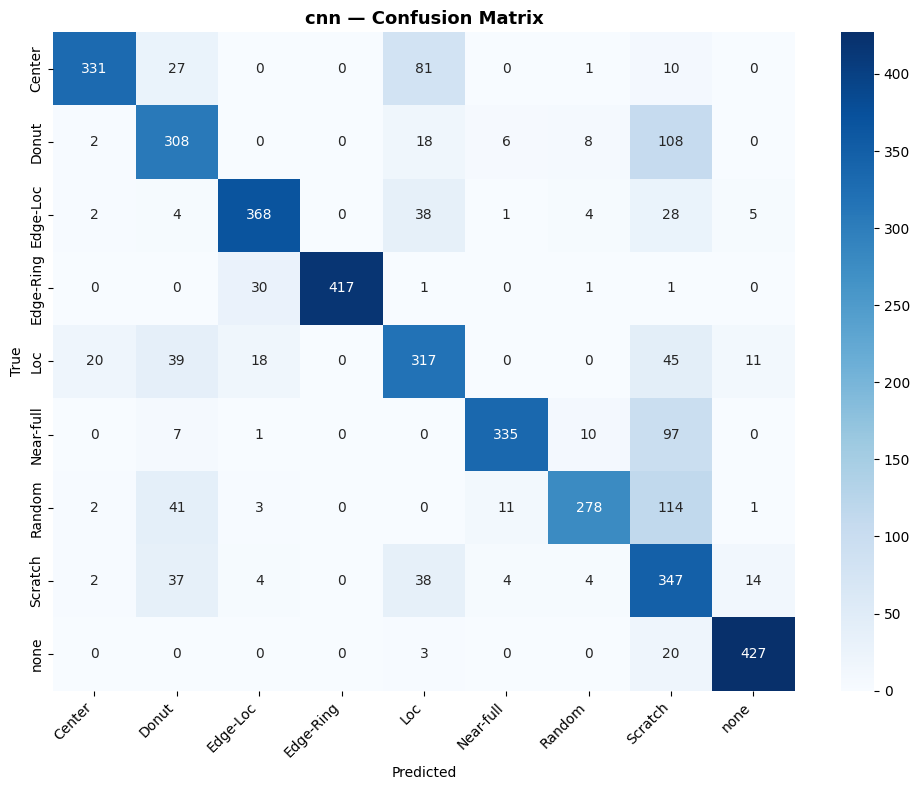

In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

def evaluate_model(model, test_loader, class_names, model_name='Model'):
    """Evaluate model and print metrics."""
    model.load_state_dict(torch.load(f'best_{model_name}.pth',
                                      map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(f'\n===== {model_name} — Test Set Evaluation =====')
    acc = accuracy_score(all_labels, all_preds)
    print(f'Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150)
    plt.show()
    return all_preds, all_labels

cnn_preds, cnn_labels = evaluate_model(
    cnn_model, test_loader, CLASS_NAMES, 'cnn')


===== hybrid — Test Set Evaluation =====
Overall Accuracy : 0.8538 (85.38%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9484    0.9800    0.9639       450
       Donut     0.7975    0.7089    0.7506       450
    Edge-Loc     0.9056    0.9378    0.9214       450
   Edge-Ring     0.9978    0.9911    0.9944       450
         Loc     0.8873    0.8222    0.8535       450
   Near-full     0.7568    0.8089    0.7820       450
      Random     0.8132    0.6867    0.7446       450
     Scratch     0.6425    0.7667    0.6991       450
        none     0.9672    0.9822    0.9746       450

    accuracy                         0.8538      4050
   macro avg     0.8573    0.8538    0.8538      4050
weighted avg     0.8573    0.8538    0.8538      4050



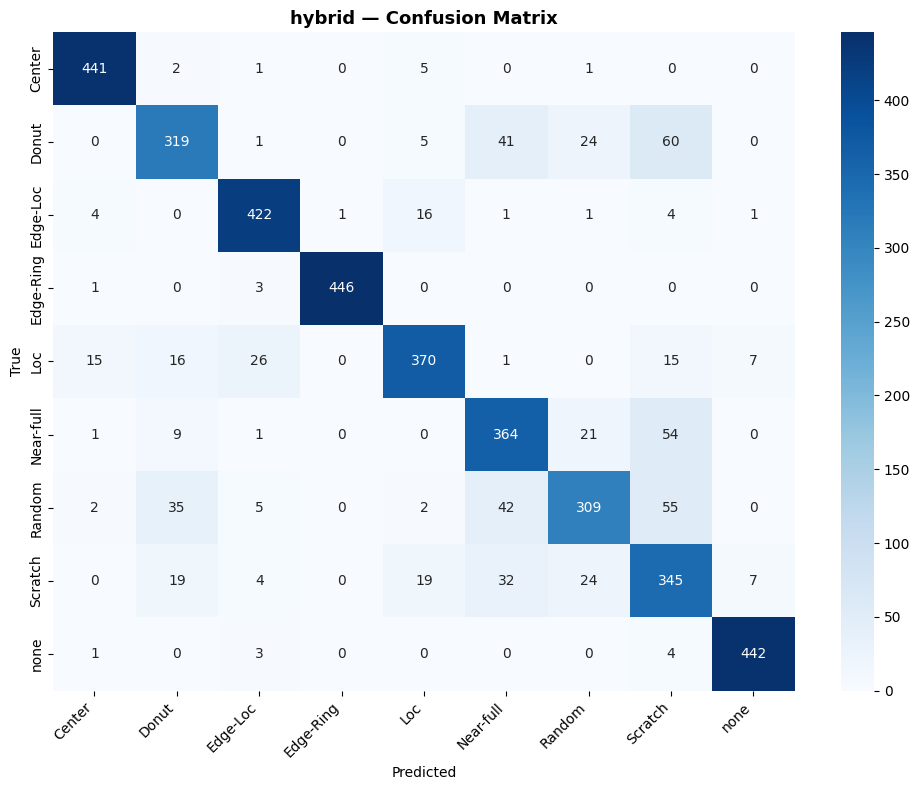

In [22]:
hybrid_preds, hybrid_labels = evaluate_model(
    hybrid_model, test_loader, CLASS_NAMES, 'hybrid')

                 Model  Accuracy  F1 (macro)
Hybrid CNN-Transformer  0.853827    0.853792
          CNN Baseline  0.772346    0.782477


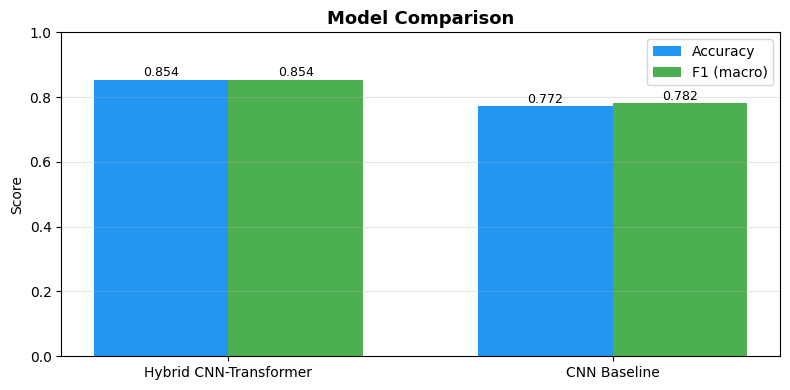

In [23]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model'    : ['CNN Baseline', 'Hybrid CNN-Transformer'],
    'Accuracy' : [
        accuracy_score(cnn_labels,    cnn_preds),
        accuracy_score(hybrid_labels, hybrid_preds),
    ],
    'F1 (macro)': [
        f1_score(cnn_labels,    cnn_preds,    average='macro'),
        f1_score(hybrid_labels, hybrid_preds, average='macro'),
    ],
}

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Accuracy'],  width, label='Accuracy',  color='#2196F3')
ax.bar(x + width/2, results_df['F1 (macro)'],width, label='F1 (macro)',color='#4CAF50')
ax.set_xticks(x); ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# EfficientAD principle:
#   • Train ONLY on 'none' (normal) wafers
#   • At test time: high reconstruction error → anomaly (unknown defect)
#   • We use a simple Autoencoder here as a lightweight stand-in;
#     for full EfficientAD paper implementation install:
#     !pip install -q efficientad
# ─────────────────────────────────────────────────────────────────────────────

class WaferAutoencoder(nn.Module):
    """Lightweight autoencoder for anomaly detection."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16
            nn.Conv2d(16, 8,  3, padding=1), nn.ReLU()                   # bottleneck
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 32, 2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae_model = WaferAutoencoder().to(DEVICE)

# ── Prepare normal-only training data ────────────────────────────────────────
none_label = le.transform(['none'])[0]
normal_mask = y_train == none_label
X_normal = X_train[normal_mask]
normal_loader = DataLoader(WaferDataset(X_normal,
                                        np.zeros(len(X_normal), dtype=np.int64)),
                           batch_size=64, shuffle=True, num_workers=0)

print(f'Normal (none) training samples: {len(X_normal)}')

Normal (none) training samples: 2100


In [25]:
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()

ae_losses = []
AE_EPOCHS = 20

print('Training Autoencoder on normal wafers...')
for epoch in range(1, AE_EPOCHS + 1):
    ae_model.train()
    total_loss = 0
    for imgs, _ in normal_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        loss = ae_criterion(recon, imgs)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg = total_loss / len(X_normal)
    ae_losses.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch}/{AE_EPOCHS}  Recon Loss: {avg:.6f}')

torch.save(ae_model.state_dict(), 'best_autoencoder.pth')
print('✅ Autoencoder trained.')

Training Autoencoder on normal wafers...
  Epoch 5/20  Recon Loss: 0.024989
  Epoch 10/20  Recon Loss: 0.018544
  Epoch 15/20  Recon Loss: 0.015324
  Epoch 20/20  Recon Loss: 0.013429
✅ Autoencoder trained.


Anomaly Threshold : 0.017465
Anomalies Detected: 2772 / 4050
Anomaly Rate      : 68.44%


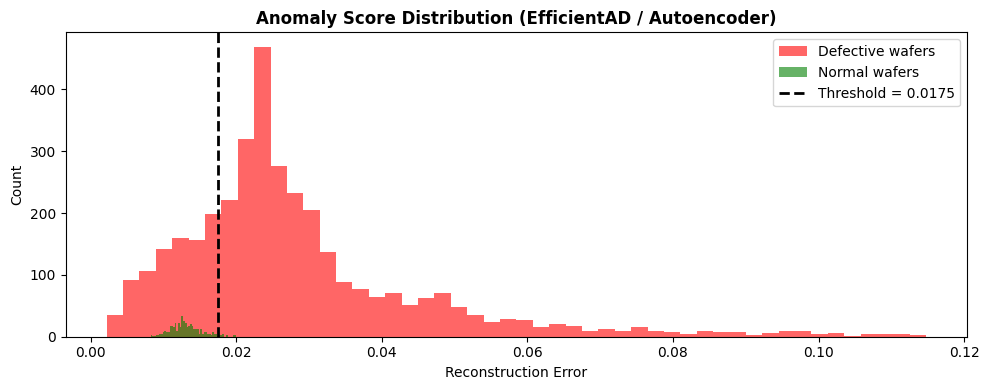

In [26]:
# ── Compute anomaly scores on test set ───────────────────────────────────────
ae_model.eval()
anomaly_scores = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        pixel_mse = ((recon - imgs) ** 2).mean(dim=(1, 2, 3))
        anomaly_scores.extend(pixel_mse.cpu().numpy())

anomaly_scores = np.array(anomaly_scores)

# Threshold: mean + 2*std on normal validation images
normal_val_mask = y_test == none_label
normal_scores = anomaly_scores[normal_val_mask]
threshold = normal_scores.mean() + 2 * normal_scores.std()
is_anomaly = anomaly_scores > threshold

print(f'Anomaly Threshold : {threshold:.6f}')
print(f'Anomalies Detected: {is_anomaly.sum()} / {len(is_anomaly)}')
print(f'Anomaly Rate      : {is_anomaly.mean()*100:.2f}%')

# Visualise anomaly score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anomaly_scores[~normal_val_mask], bins=50, alpha=0.6,
        label='Defective wafers', color='red')
ax.hist(anomaly_scores[ normal_val_mask], bins=50, alpha=0.6,
        label='Normal wafers',   color='green')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.4f}')
ax.set_title('Anomaly Score Distribution (EfficientAD / Autoencoder)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150)
plt.show()

True Label: none


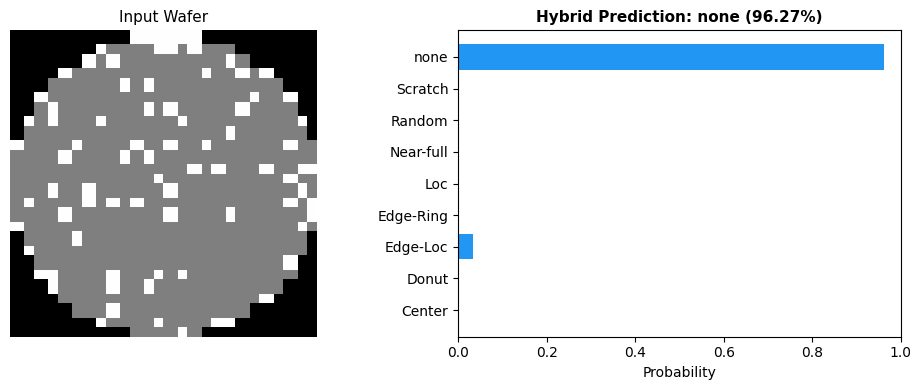

Predicted  : none (96.27% confidence)


In [27]:
def predict_single(model, img_array, class_names, model_name='Model'):
    """
    Predict defect class for a single wafer image.
    img_array: numpy array (H, W, 3) float32 in [0, 1]
    """
    model.eval()
    tensor = torch.tensor(img_array).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_cls  = class_names[np.argmax(probs)]
    confidence = probs.max()

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_array)
    ax1.set_title(f'Input Wafer', fontsize=11)
    ax1.axis('off')
    ax2.barh(class_names, probs, color='#2196F3')
    ax2.set_xlim(0, 1)
    ax2.set_title(f'{model_name} Prediction: {pred_cls} ({confidence:.2%})',
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel('Probability')
    plt.tight_layout()
    plt.savefig(f'prediction_{model_name}.png', dpi=150)
    plt.show()
    return pred_cls, confidence, probs

# Demo with a random test sample
sample_idx   = 10
sample_img   = X_test[sample_idx]   # (64, 64, 3) float32
true_label   = CLASS_NAMES[y_test[sample_idx]]
print(f'True Label: {true_label}')

pred_cls, conf, probs = predict_single(
    hybrid_model, sample_img, CLASS_NAMES, 'Hybrid')
print(f'Predicted  : {pred_cls} ({conf:.2%} confidence)')

True Label: Edge-Loc


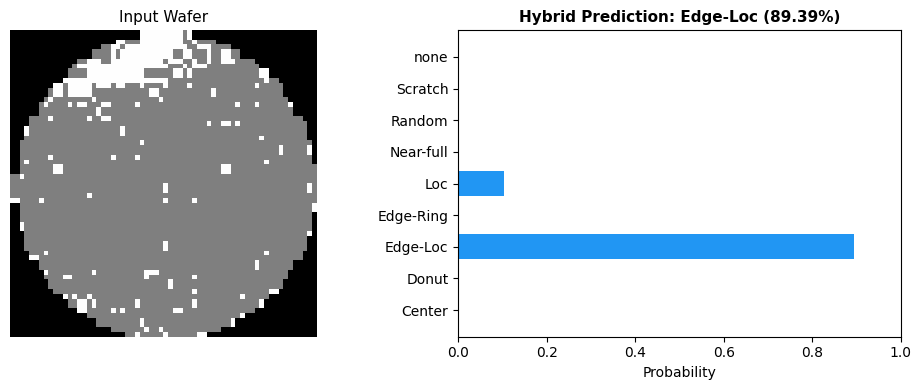

Predicted  : Edge-Loc (89.39% confidence)


In [30]:
# Demo with a random test sample
sample_idx   = np.random.randint(len(X_test))
sample_img   = X_test[sample_idx]   # (64, 64, 3) float32
true_label   = CLASS_NAMES[y_test[sample_idx]]
print(f'True Label: {true_label}')

pred_cls, conf, probs = predict_single(
    hybrid_model, sample_img, CLASS_NAMES, 'Hybrid')
print(f'Predicted  : {pred_cls} ({conf:.2%} confidence)')